# **Trends in Heatwaves for Mornington Peninsula**

**Study Period:** 1910-2025

**Heatwave Definition:**
 - Based on Perkins, S. E., & Alexander, L. V. (2013). On the measurement of heatwave. Journal of Climate, 26(13), 4500-4517.

**Script Order:**
 - First script: Heatwave Austral Summer (Nov-Mar)
 - Second script: Heatwave Austral Winter (Apr-Oct)

tmax shape: (42369, 10, 14) (lat: 10, lon: 14, time: 42369)
tmin shape: (42369, 10, 14) (lat: 10, lon: 14, time: 42369)
Tmax series: 1910-01-01 to 2025-12-31 (42369 days)
Tmin series: 1910-01-01 to 2025-12-31 (42369 days)
TX90 climatology built: 0.1s
TN90 climatology built: 0.1s
df rows after dropna: 42369
season_df rows (Nov-Mar): 17545
TX90 non-null: 42369 / 42369
TN90 non-null: 42369 / 42369
season_years found: [1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005,

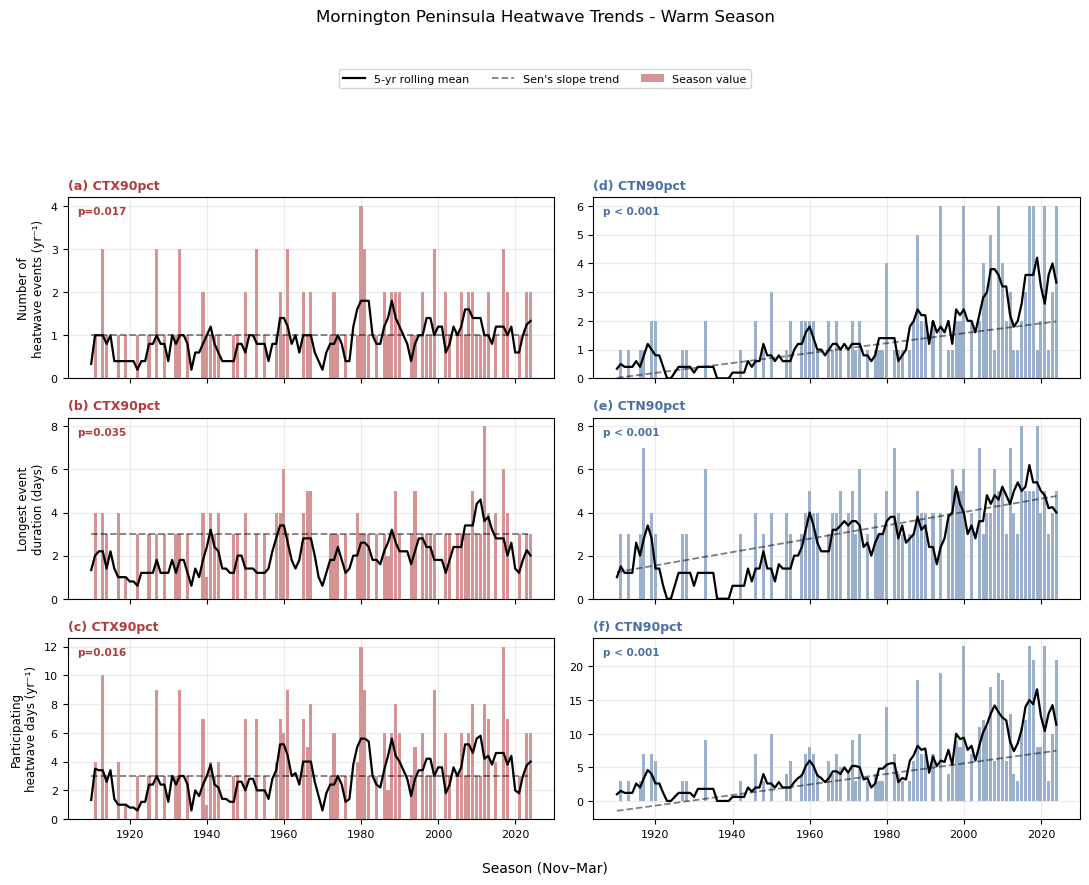

In [3]:
import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pymannkendall as mk


# Configuration

# Mornington Peninsula bounding box
MIN_LAT, MAX_LAT = -38.50, -38.05
MIN_LON, MAX_LON = 144.68, 145.35

CLIM_START, CLIM_END = 1961, 1990
DOY_WINDOW = 15
PCTL = 90
MIN_RUN_LENGTH = 3

SEASON_MONTHS = [11, 12, 1, 2, 3]
SEASON_START_MONTH = 11

OUT_DIR = '/home/563/ft3359/RA-MorningtonPeninsula/Figures'
os.makedirs(OUT_DIR, exist_ok=True)


CACHE_DIR = '/scratch/ob22/ft3359/mornington_cache'


# Load cached tmax / tmin (already cropped to the box and land-masked)

tmax_grid = xr.open_dataarray(f'{CACHE_DIR}/tmax_grid_masked.nc').load()
tmin_grid = xr.open_dataarray(f'{CACHE_DIR}/tmin_grid_masked.nc').load()

print(f"tmax shape: {tmax_grid.shape} (lat: {tmax_grid.lat.size}, "
      f"lon: {tmax_grid.lon.size}, time: {tmax_grid.time.size})")
print(f"tmin shape: {tmin_grid.shape} (lat: {tmin_grid.lat.size}, "
      f"lon: {tmin_grid.lon.size}, time: {tmin_grid.time.size})")

TX = tmax_grid.mean(dim=['lat', 'lon'], skipna=True).to_series()
TN = tmin_grid.mean(dim=['lat', 'lon'], skipna=True).to_series()

for s in (TX, TN):
    s.index = pd.to_datetime(s.index).normalize()
TX = TX.sort_index()
TN = TN.sort_index()
TX = TX[~TX.index.duplicated()]
TN = TN[~TN.index.duplicated()]

print(f"Tmax series: {TX.index.min().date()} to {TX.index.max().date()} ({len(TX)} days)")
print(f"Tmin series: {TN.index.min().date()} to {TN.index.max().date()} ({len(TN)} days)")


# Calendar-day 90th-percentile climatology

def build_doy(index):
    doy = index.dayofyear
    shift = (index.is_leap_year) & (doy > 59)
    return np.where(shift, doy - 1, doy)


def calendar_day_percentile(series, clim_start, clim_end, pctl, window):
    avail_start_year = series.index.min().year
    if clim_start < avail_start_year:
        clim_start = avail_start_year
        clim_end = clim_start + 29
        print(f"Reference period adjusted to {clim_start}-{clim_end} "
              f"(record doesn't reach {CLIM_START})")

    mask = (series.index.year >= clim_start) & (series.index.year <= clim_end)
    ref = series[mask].dropna()
    ref = ref[~((ref.index.month == 2) & (ref.index.day == 29))]
    ref_doy = build_doy(ref.index)
    ref_vals = ref.values

    all_days = np.arange(1, 366)
    diff = np.abs(ref_doy[:, None] - all_days[None, :])
    circ_diff = np.minimum(diff, 365 - diff)
    thresholds = {}
    for i, d in enumerate(all_days):
        vals = ref_vals[circ_diff[:, i] <= window]
        thresholds[d] = np.nanpercentile(vals, pctl) if len(vals) > 0 else np.nan

    full_doy = build_doy(series.index)
    return pd.Series(full_doy, index=series.index).map(thresholds)


_t0 = pd.Timestamp.now()
TX90 = calendar_day_percentile(TX, CLIM_START, CLIM_END, PCTL, DOY_WINDOW)
print(f"TX90 climatology built: {(pd.Timestamp.now() - _t0).total_seconds():.1f}s")
_t0 = pd.Timestamp.now()
TN90 = calendar_day_percentile(TN, CLIM_START, CLIM_END, PCTL, DOY_WINDOW)
print(f"TN90 climatology built: {(pd.Timestamp.now() - _t0).total_seconds():.1f}s")


# Flag exceedance days and qualifying heatwave events (>= 3 consecutive)

def flag_heatwave_days(values, thresholds, min_run):
    exceed = (values > thresholds).astype(int)
    run_id = (exceed != exceed.shift()).cumsum()
    run_length = exceed.groupby(run_id).transform('size') * exceed
    is_hw_day = (exceed == 1) & (run_length >= min_run)
    event_id = np.where(is_hw_day, run_id, np.nan)
    return is_hw_day, event_id


tx_is_hw, tx_event_id = flag_heatwave_days(TX, TX90, MIN_RUN_LENGTH)
tn_is_hw, tn_event_id = flag_heatwave_days(TN, TN90, MIN_RUN_LENGTH)

df = pd.DataFrame({
    'TX': TX, 'TN': TN,
    'TX90': TX90, 'TN90': TN90,
    'tx_is_hw': tx_is_hw, 'tx_event_id': tx_event_id,
    'tn_is_hw': tn_is_hw, 'tn_event_id': tn_event_id,
}).dropna(subset=['TX90', 'TN90'])


# Restrict to the Nov-Mar season

season_df = df[df.index.month.isin(SEASON_MONTHS)].copy()
season_df['season_year'] = np.where(
    season_df.index.month >= SEASON_START_MONTH,
    season_df.index.year,
    season_df.index.year - 1
)


# Diagnostics

print(f"df rows after dropna: {len(df)}")
print(f"season_df rows (Nov-Mar): {len(season_df)}")
print(f"TX90 non-null: {TX90.notna().sum()} / {len(TX90)}")
print(f"TN90 non-null: {TN90.notna().sum()} / {len(TN90)}")
print(f"season_years found: "
      f"{sorted(season_df['season_year'].unique()) if len(season_df) else 'NONE'}")


# Annual aspects

def compute_aspects(season_df, var_col, is_hw_col, event_id_col):
    columns = ['season_year', 'HWN', 'HWD', 'HWF', 'HWA', 'HWM']
    records = []
    for yr, grp in season_df.groupby('season_year'):
        season_mean = grp[var_col].mean()
        hw_days = grp[grp[is_hw_col]]
        n_events = hw_days[event_id_col].nunique()
        if len(hw_days) > 0:
            event_lengths = hw_days.groupby(event_id_col).size()
            hwd = event_lengths.max()
            hwa = hw_days[var_col].max() - season_mean
            hwm = hw_days[var_col].mean() - season_mean
        else:
            hwd, hwa, hwm = 0, np.nan, np.nan
        records.append({'season_year': yr, 'HWN': n_events, 'HWD': hwd,
                         'HWF': len(hw_days), 'HWA': hwa, 'HWM': hwm})
    out = pd.DataFrame(records, columns=columns).set_index('season_year').sort_index()
    if len(out) > 2:
        out = out.loc[out.index[1:-1]]
    return out


ctx_metrics = compute_aspects(season_df, 'TX', 'tx_is_hw', 'tx_event_id')
ctn_metrics = compute_aspects(season_df, 'TN', 'tn_is_hw', 'tn_event_id')

if ctx_metrics.empty or ctn_metrics.empty:
    raise RuntimeError(
        "No seasons with data made it through to ctx_metrics/ctn_metrics. "
        "Check the diagnostic counts printed above -- most likely TX90/TN90 "
        "came back all-NaN (climatology reference period not overlapping "
        "the loaded record) or season_df is empty (check df.index.month "
        "and that the time coordinate decoded to a normal DatetimeIndex)."
    )

print("CTX90pct annual aspects (tail):")
print(ctx_metrics.tail())
print("\nCTN90pct annual aspects (tail):")
print(ctn_metrics.tail())


# Trend statistics

def trend_stats(series, min_n=8):
    s = series.dropna()
    if len(s) < min_n:
        return {'trend': 'insufficient data', 'p': np.nan, 'slope': np.nan, 'n': len(s)}
    result = mk.original_test(s.values)
    return {'trend': result.trend, 'p': result.p, 'slope': result.slope, 'n': len(s)}


def fmt_p(p):
    if np.isnan(p):
        return "insufficient data"
    return "p < 0.001" if p < 0.001 else f"p={p:.3f}"


def fmt_trend_label(stats):
    if np.isnan(stats['p']):
        return f"insufficient data (n={stats['n']})"
    sig = 'significant' if stats['p'] < 0.05 else 'not significant'
    return f"MK trend: {stats['trend']} ({sig}, {fmt_p(stats['p'])})"

aspect_labels = {
    'HWN': 'Number of\nheatwave events (yr\u207b\u00b9)',
    'HWD': 'Longest event\nduration (days)',
    'HWF': 'Participating\nheatwave days (yr\u207b\u00b9)',
}
COUNT_ASPECTS = {'HWN', 'HWD', 'HWF'}

trend_results = {'CTX90pct': {}, 'CTN90pct': {}}
for col in aspect_labels:
    trend_results['CTX90pct'][col] = trend_stats(ctx_metrics[col])
    trend_results['CTN90pct'][col] = trend_stats(ctn_metrics[col])
    print(f"CTX90pct {col}: {fmt_trend_label(trend_results['CTX90pct'][col])}")
    print(f"CTN90pct {col}: {fmt_trend_label(trend_results['CTN90pct'][col])}")


# Plots

definitions = ['CTX90pct', 'CTN90pct']
colors = {'CTX90pct': '#B33A3A', 'CTN90pct': '#4A6FA5'}
metrics_by_def = {'CTX90pct': ctx_metrics, 'CTN90pct': ctn_metrics}

panel_letters = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
panel_idx = 0

n_rows = len(aspect_labels)
fig, axes = plt.subplots(n_rows, 2, figsize=(11, 2.6 * n_rows), sharex='col')

for j, defn in enumerate(definitions):
    metrics = metrics_by_def[defn]
    color = colors[defn]
    for i, (col, label) in enumerate(aspect_labels.items()):
        ax = axes[i, j]
        y = metrics[col]
        stats = trend_results[defn][col]

        ax.bar(y.index, y.values, color=color, alpha=0.55, width=0.8,
               label='Season value')

        roll = y.rolling(5, center=True, min_periods=3).mean()
        ax.plot(roll.index, roll.values, color='black', lw=1.6,
                 label='5-yr rolling mean')

        if not np.isnan(stats['slope']):
            x = y.dropna().index.values.astype(float)
            median_x = np.median(x)
            median_y = np.median(y.dropna().values)
            sen_line = median_y + stats['slope'] * (x - median_x)
            ax.plot(x, sen_line, ls='--', lw=1.3, color='black', alpha=0.5,
                     label="Sen's slope trend")

        sig = stats['p'] < 0.05 if not np.isnan(stats['p']) else False
        title_weight = 'bold' if sig else 'normal'
        ax.set_title(f'{panel_letters[panel_idx]} {defn}', fontsize=9, weight=title_weight,
                      color=color if sig else '#333333', loc='left')
        panel_idx += 1

        ax.text(0.02, 0.95, fmt_p(stats['p']), transform=ax.transAxes, fontsize=7.5,
                 va='top', ha='left',
                 color=color if sig else '#666666',
                 weight='bold' if sig else 'normal')

        if j == 0:
            ax.set_ylabel(label, fontsize=8.5)
        ax.grid(alpha=0.25)
        ax.tick_params(labelsize=8)

fig.supxlabel('Season (Nov\u2013Mar)', fontsize=10)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=8,
           bbox_to_anchor=(0.5, 1.05))
fig.suptitle('Mornington Peninsula Heatwave Trends - Warm Season', fontsize=12, y=1.12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(f'{OUT_DIR}/mornington_heatwave_ctx_ctn_trends.png', dpi=200,
            bbox_inches='tight')
print(f"Saved figure to {OUT_DIR}/mornington_heatwave_ctx_ctn_trends.png")

Reusing TX/TN series already in memory: 1910-01-01 to 2025-12-31 (42369 days)
df rows after dropna: 42369
season_df rows (Apr-Oct): 24824
TX90 non-null: 42369 / 42369
TN90 non-null: 42369 / 42369
season_years found: [1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
CTX90pct annual aspects (tail):
             HWN  HWD  HWF        HWA       HWM
season_

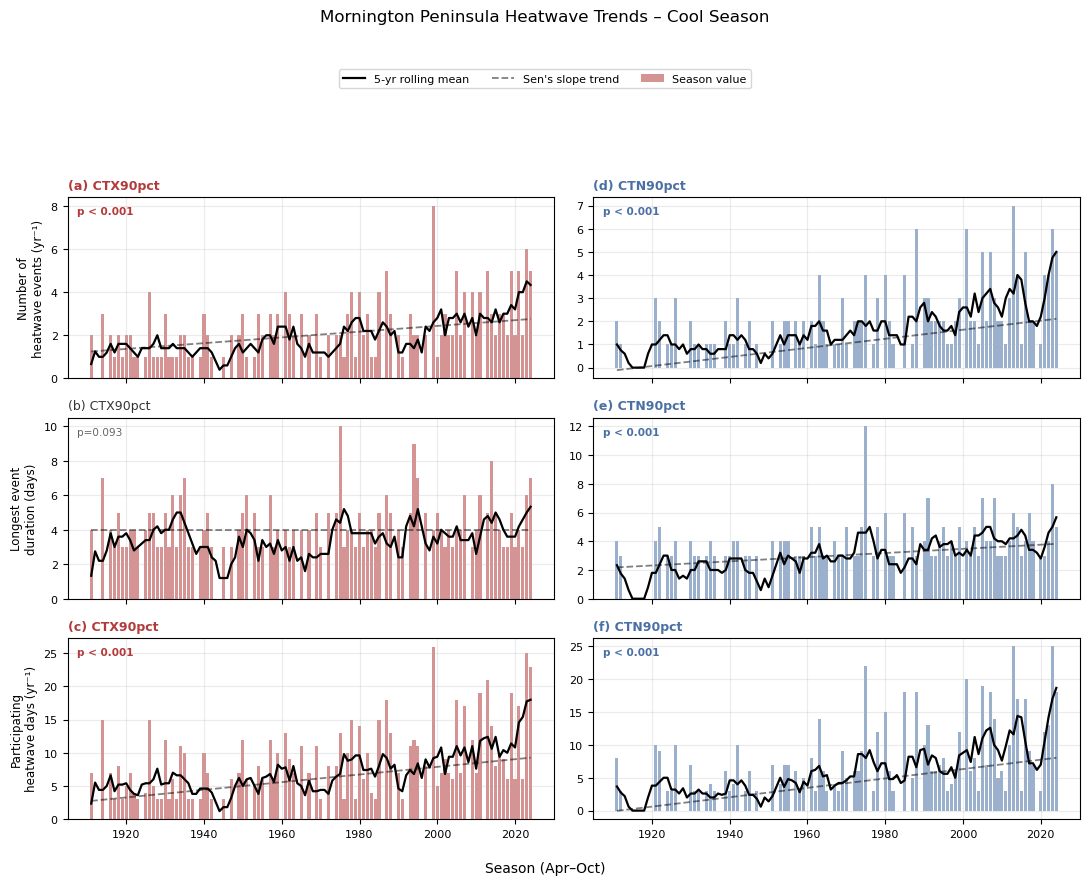

In [5]:
import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pymannkendall as mk

# Configuration

# Mornington Peninsula bounding box (kept for reference)
MIN_LAT, MAX_LAT = -38.50, -38.05
MIN_LON, MAX_LON = 144.68, 145.35

MIN_RUN_LENGTH = 3

SEASON_MONTHS = [4, 5, 6, 7, 8, 9, 10]
SEASON_START_MONTH = 4

OUT_DIR = '/home/563/ft3359/RA-MorningtonPeninsula/Figures'
os.makedirs(OUT_DIR, exist_ok=True)

print(f"Reusing TX/TN series already in memory: "
      f"{TX.index.min().date()} to {TX.index.max().date()} ({len(TX)} days)")


# Flag exceedance days and qualifying heatwave events (>= 3 consecutive)

def flag_heatwave_days(values, thresholds, min_run):
    exceed = (values > thresholds).astype(int)
    run_id = (exceed != exceed.shift()).cumsum()
    run_length = exceed.groupby(run_id).transform('size') * exceed
    is_hw_day = (exceed == 1) & (run_length >= min_run)
    event_id = np.where(is_hw_day, run_id, np.nan)
    return is_hw_day, event_id


tx_is_hw, tx_event_id = flag_heatwave_days(TX, TX90, MIN_RUN_LENGTH)
tn_is_hw, tn_event_id = flag_heatwave_days(TN, TN90, MIN_RUN_LENGTH)

df = pd.DataFrame({
    'TX': TX, 'TN': TN,
    'TX90': TX90, 'TN90': TN90,
    'tx_is_hw': tx_is_hw, 'tx_event_id': tx_event_id,
    'tn_is_hw': tn_is_hw, 'tn_event_id': tn_event_id,
}).dropna(subset=['TX90', 'TN90'])


# Restrict to the Apr-Oct cool season

season_df = df[df.index.month.isin(SEASON_MONTHS)].copy()
season_df['season_year'] = np.where(
    season_df.index.month >= SEASON_START_MONTH,
    season_df.index.year,
    season_df.index.year - 1
)


# Diagnostics

print(f"df rows after dropna: {len(df)}")
print(f"season_df rows (Apr-Oct): {len(season_df)}")
print(f"TX90 non-null: {TX90.notna().sum()} / {len(TX90)}")
print(f"TN90 non-null: {TN90.notna().sum()} / {len(TN90)}")
print(f"season_years found: "
      f"{sorted(season_df['season_year'].unique()) if len(season_df) else 'NONE'}")


# Annual aspects

def compute_aspects(season_df, var_col, is_hw_col, event_id_col):
    columns = ['season_year', 'HWN', 'HWD', 'HWF', 'HWA', 'HWM']
    records = []
    for yr, grp in season_df.groupby('season_year'):
        season_mean = grp[var_col].mean()
        hw_days = grp[grp[is_hw_col]]
        n_events = hw_days[event_id_col].nunique()
        if len(hw_days) > 0:
            event_lengths = hw_days.groupby(event_id_col).size()
            hwd = event_lengths.max()
            hwa = hw_days[var_col].max() - season_mean
            hwm = hw_days[var_col].mean() - season_mean
        else:
            hwd, hwa, hwm = 0, np.nan, np.nan
        records.append({'season_year': yr, 'HWN': n_events, 'HWD': hwd,
                         'HWF': len(hw_days), 'HWA': hwa, 'HWM': hwm})
    out = pd.DataFrame(records, columns=columns).set_index('season_year').sort_index()
    if len(out) > 2:
        out = out.loc[out.index[1:-1]]
    return out


ctx_metrics = compute_aspects(season_df, 'TX', 'tx_is_hw', 'tx_event_id')
ctn_metrics = compute_aspects(season_df, 'TN', 'tn_is_hw', 'tn_event_id')

if ctx_metrics.empty or ctn_metrics.empty:
    raise RuntimeError(
        "No seasons with data made it through to ctx_metrics/ctn_metrics. "
        "Check the diagnostic counts printed above -- most likely TX90/TN90 "
        "came back all-NaN (climatology reference period not overlapping "
        "the loaded record) or season_df is empty (check df.index.month "
        "and that the time coordinate decoded to a normal DatetimeIndex)."
    )

print("CTX90pct annual aspects (tail):")
print(ctx_metrics.tail())
print("\nCTN90pct annual aspects (tail):")
print(ctn_metrics.tail())


# Trend statistics

def trend_stats(series, min_n=8):
    s = series.dropna()
    if len(s) < min_n:
        return {'trend': 'insufficient data', 'p': np.nan, 'slope': np.nan, 'n': len(s)}
    result = mk.original_test(s.values)
    return {'trend': result.trend, 'p': result.p, 'slope': result.slope, 'n': len(s)}


def fmt_p(p):
    if np.isnan(p):
        return "insufficient data"
    return "p < 0.001" if p < 0.001 else f"p={p:.3f}"


def fmt_trend_label(stats):
    if np.isnan(stats['p']):
        return f"insufficient data (n={stats['n']})"
    sig = 'significant' if stats['p'] < 0.05 else 'not significant'
    return f"MK trend: {stats['trend']} ({sig}, {fmt_p(stats['p'])})"


aspect_labels = {
    'HWN': 'Number of\nheatwave events (yr\u207b\u00b9)',
    'HWD': 'Longest event\nduration (days)',
    'HWF': 'Participating\nheatwave days (yr\u207b\u00b9)',
}
COUNT_ASPECTS = {'HWN', 'HWD', 'HWF'}

trend_results = {'CTX90pct': {}, 'CTN90pct': {}}
for col in aspect_labels:
    trend_results['CTX90pct'][col] = trend_stats(ctx_metrics[col])
    trend_results['CTN90pct'][col] = trend_stats(ctn_metrics[col])
    print(f"CTX90pct {col}: {fmt_trend_label(trend_results['CTX90pct'][col])}")
    print(f"CTN90pct {col}: {fmt_trend_label(trend_results['CTN90pct'][col])}")


# Plots

definitions = ['CTX90pct', 'CTN90pct']
colors = {'CTX90pct': '#B33A3A', 'CTN90pct': '#4A6FA5'}
metrics_by_def = {'CTX90pct': ctx_metrics, 'CTN90pct': ctn_metrics}

panel_letters = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
panel_idx = 0

n_rows = len(aspect_labels)
fig, axes = plt.subplots(n_rows, 2, figsize=(11, 2.6 * n_rows), sharex='col')

for j, defn in enumerate(definitions):
    metrics = metrics_by_def[defn]
    color = colors[defn]
    for i, (col, label) in enumerate(aspect_labels.items()):
        ax = axes[i, j]
        y = metrics[col]
        stats = trend_results[defn][col]

        ax.bar(y.index, y.values, color=color, alpha=0.55, width=0.8,
               label='Season value')

        roll = y.rolling(5, center=True, min_periods=3).mean()
        ax.plot(roll.index, roll.values, color='black', lw=1.6,
                 label='5-yr rolling mean')

        if not np.isnan(stats['slope']):
            x = y.dropna().index.values.astype(float)
            median_x = np.median(x)
            median_y = np.median(y.dropna().values)
            sen_line = median_y + stats['slope'] * (x - median_x)
            ax.plot(x, sen_line, ls='--', lw=1.3, color='black', alpha=0.5,
                     label="Sen's slope trend")

        sig = stats['p'] < 0.05 if not np.isnan(stats['p']) else False
        title_weight = 'bold' if sig else 'normal'
        ax.set_title(f'{panel_letters[panel_idx]} {defn}', fontsize=9, weight=title_weight,
                      color=color if sig else '#333333', loc='left')
        panel_idx += 1

        ax.text(0.02, 0.95, fmt_p(stats['p']), transform=ax.transAxes, fontsize=7.5,
                 va='top', ha='left',
                 color=color if sig else '#666666',
                 weight='bold' if sig else 'normal')

        if j == 0:
            ax.set_ylabel(label, fontsize=8.5)
        ax.grid(alpha=0.25)
        ax.tick_params(labelsize=8)

fig.supxlabel('Season (Apr\u2013Oct)', fontsize=10)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=8,
           bbox_to_anchor=(0.5, 1.05))
fig.suptitle('Mornington Peninsula Heatwave Trends \u2013 Cool Season',
             fontsize=12, y=1.12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(f'{OUT_DIR}/mornington_heatwave_trends_winter.png', dpi=200,
            bbox_inches='tight')
print(f"Saved figure to {OUT_DIR}/mornington_heatwave_trends_winter.png")